# Notebook 02 - Corridor Incident: Impact Dynamics

Author: Stellars Henson<br>
Approach: a lumped-parameter dynamics model of the back-first impact.  Notebook 01's kinematics envelope delivers Victoria's body to the elevator door at a closing velocity of 2.4-2.7 m/s; this notebook takes over at contact and asks whether the impact could fracture ribs or vertebrae.

The modelling lives in the `henryk_simulations.corridor.impact` library; this notebook is a thin client over it - it presents the body-segment model, the effective impacting mass, the posterior contact patches, the 5-DOF posterior-thorax chain, the fracture thresholds and the verdict.

## Model decisions

- **Lumped-parameter, no FEM.**  The body is a 5-DOF mass-spring-damper chain - skin, scapula, ribcage, organ, spine - the Lobdell-style posterior-thorax model.  Forces and deflections are scored against published fracture corridors.
- **Rigid door.**  The elevator door (ZREMB DT37/1, 3 mm steel) is modelled as a rigid wall - the worst case for the body.  A real door flexes and would lower the load; an FE-coupled door is left to a later notebook.
- **Worst case for the accusation.**  The rigid door, and a chain that lumps the whole body mass behind the contact, both maximise the computed force.  If even this does not fracture, a gentler reading does not either.


In [1]:
# Imports
from __future__ import annotations

import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the impact modelling lives in the corridor submodule
from henryk_simulations.corridor import (
    ImpactConfig,
    assess_fracture,
    body_segments,
    contact_area,
    effective_impact_mass,
    fracture_thresholds,
    predict_injuries,
    solve_impact,
)
from henryk_simulations.corridor.impact import POSTERIOR_PATCHES
from henryk_simulations.corridor.choreography import ChoreographyConfig, solve_envelope

console = Console()
sns.set_theme(style="whitegrid", context="notebook")


2026-05-19 13:04:49.416 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)


## The Scene

Notebook 01 stopped at the door.  Its kinematics envelope - the no-coast and with-coast bracketing solutions - delivers Victoria's centre of mass to the elevator door at a **closing velocity of 2.4 to 2.7 m/s**.  This notebook starts at that instant: the body, moving back-first, meets the door.

The door is the ZREMB DT37/1 elevator leaf - a 3 mm steel sheet.  Here it is modelled as a **rigid wall**.  A real panel flexes (its first bending mode is near 37 Hz) and a flexing panel takes up energy that would otherwise load the body, so the rigid-door result is an **upper bound** on the force the body sees.


In [3]:
# Closing velocity from notebook 01's kinematics envelope
no_coast, with_coast = solve_envelope(ChoreographyConfig())
V_FAST = no_coast.v_close
V_SLOW = with_coast.v_close
console.print(
    f"Notebook 01 kinematics envelope delivers the body at "
    f"[bold]v_close = {V_SLOW:.2f} - {V_FAST:.2f} m/s[/bold] "
    f"(with-coast to no-coast)."
)
console.print(
    "Door: ZREMB DT37/1 elevator leaf, 3 mm steel sheet - modelled as a "
    "rigid wall (the worst case for the body)."
)


Notebook 01 kinematics envelope delivers the body at v_close = 2.35 - 2.74 m/s (with-coast to no-coast).

Door: ZREMB DT37/1 elevator leaf, 3 mm steel sheet - modelled as a rigid wall (the worst case for the body).

## Configuration

`ImpactConfig` from the corridor library is the single configuration object for this notebook - the body mass, the 5-DOF chain (masses, stiffnesses, dampings), the skin-to-door contact, the yield plateau, and the contact-patch parameters.  Every section below reads from it.


In [4]:
IMPACT = ImpactConfig(subject_gender="F", subject_age=38.0)  # Victoria
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="grey70")
cfg_tbl.add_column("value")
for f in dataclasses.fields(IMPACT):
    cfg_tbl.add_row(f.name, f"[white]{getattr(IMPACT, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold medium_purple]ImpactConfig[/bold medium_purple]",
                    border_style="medium_purple"))


╭───────────────────────────────────────────────── ImpactConfig ──────────────────────────────────────────────────╮
│   body_mass             70.0                                                                                    │
│   body_height           1.68                                                                                    │
│   subject_gender        F                                                                                       │
│   subject_age           38.0                                                                                    │
│   m_skin_fraction       0.02                                                                                    │
│   m_scapula_fraction    0.04                                                                                    │
│   m_ribcage_fraction    0.14                                                                                    │
│   m_organ_fraction      0.22                                                                                    │
│   m_spine_fraction      0.58                                                                                    │
│   k_skin                200000.0                                                                                │
│   k_scapula             800000.0                                                                                │
│   k_rib                 350000.0                                                                                │
│   k_spine               600000.0                                                                                │
│   c_skin                800.0                                                                                   │
│   c_scapula             1500.0                                                                                  │
│   c_rib                 1200.0                                                                                  │
│   c_spine               2000.0                                                                                  │
│   k_contact             5000000.0                                                                               │
│   n_contact             1.5                                                                                     │
│   lambda_hc             1.5                                                                                     │
│   yield_force           9000.0                                                                                  │
│   area_initial          0.01                                                                                    │
│   area_final            0.06                                                                                    │
│   area_tau              0.015                                                                                   │
│   n_ribs_span           7                                                                                       │
│   t_max                 0.15                                                                                    │
│   n_eval                1500                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Body Segment Model

The body is not a 70 kg point.  The de Leva (1996) segment-inertia tables - the standard adjusted Zatsiorsky-Seluyanov parameters - break a 70 kg adult into head, trunk (thorax, abdomen, pelvis) and the paired limb segments.  The split that matters for a back-first impact is **back versus limb**: the head and trunk lie directly behind the contact, the arms and legs hang on their joints.


  Body segments - de Leva (1996), 70 kg  
                  adult                  
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┓
┃ Segment   ┃ Group ┃ Count ┃ Mass (kg) ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━┩
│ head      │ back  │     1 │       4.9 │
│ thorax    │ back  │     1 │      11.2 │
│ abdomen   │ back  │     1 │      11.4 │
│ pelvis    │ back  │     1 │       7.8 │
│ upper arm │ limb  │     2 │       3.8 │
│ forearm   │ limb  │     2 │       2.3 │
│ hand      │ limb  │     2 │       0.9 │
│ thigh     │ limb  │     2 │      19.8 │
│ shank     │ limb  │     2 │       6.1 │
│ foot      │ limb  │     2 │       1.9 │
└───────────┴───────┴───────┴───────────┘

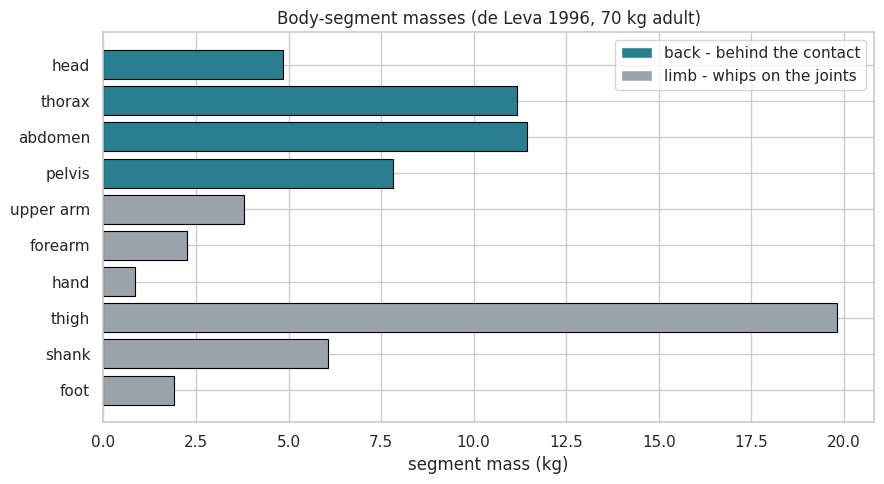

In [5]:
segs = body_segments(IMPACT)

seg_tbl = Table(title="[bold medium_purple]Body segments - de Leva (1996), 70 kg adult[/bold medium_purple]",
                show_header=True, header_style="bold slate_blue1")
seg_tbl.add_column("Segment")
seg_tbl.add_column("Group")
seg_tbl.add_column("Count", justify="right")
seg_tbl.add_column("Mass (kg)", justify="right")
for s in segs:
    seg_tbl.add_row(s.name, s.group, str(s.count), f"{s.mass:.1f}")
console.print(seg_tbl)

fig, ax = plt.subplots(figsize=(9, 5))
names = [s.name for s in segs]
masses = [s.mass for s in segs]
colors = ["#2a7f8f" if s.group == "back" else "#9aa3ab" for s in segs]
y = np.arange(len(segs))
ax.barh(y, masses, color=colors, edgecolor="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("segment mass (kg)")
ax.set_title("Body-segment masses (de Leva 1996, 70 kg adult)")
back_patch = plt.Rectangle((0, 0), 1, 1, fc="#2a7f8f")
limb_patch = plt.Rectangle((0, 0), 1, 1, fc="#9aa3ab")
ax.legend([back_patch, limb_patch],
          ["back - behind the contact", "limb - whips on the joints"])
fig.tight_layout()
fig.savefig(FIG_DIR / "02-body-segments.png", dpi=140, bbox_inches="tight")
plt.show()


## Effective Impacting Mass

A back-first impact does not drive all 70 kg into the door at once.  The back segments couple immediately - they are the back.  The limbs hang on the shoulder and hip joints; over the ~40 ms of the impact a joint transmits only part of a limb's deceleration, so the limbs whip rather than load the contact.  The effective impacting mass is therefore an **envelope**: a lower bound where the limbs are fully free, an upper bound where the whole body is rigid.

The impact chain below still lumps the **full 70 kg** - the rigid upper bound.  That is the conservative choice: it maximises the force.


In [6]:
em = effective_impact_mass(IMPACT)

em_tbl = Table(show_header=False, box=None, padding=(0, 2))
em_tbl.add_column("", style="grey70")
em_tbl.add_column("")
em_tbl.add_row("back (head + trunk)", f"{em.m_back:.1f} kg")
em_tbl.add_row("limbs (arms + legs)", f"{em.m_limbs:.1f} kg")
em_tbl.add_row("effective impacting mass", f"{em.m_eff_low:.0f} - {em.m_eff_high:.0f} kg")
console.print(Panel(em_tbl, title="[bold medium_purple]Effective impacting mass[/bold medium_purple]",
                    border_style="medium_purple"))
console.print(
    f"The back segments ({em.m_back:.0f} kg) sit directly behind the contact; "
    f"the limbs ({em.m_limbs:.0f} kg) whip on their joints.  The chain lumps the "
    f"full {IMPACT.body_mass:.0f} kg - the rigid worst case."
)


╭─────────────────────────────────────────── Effective impacting mass ────────────────────────────────────────────╮
│   back (head + trunk)         35.3 kg                                                                           │
│   limbs (arms + legs)         34.7 kg                                                                           │
│   effective impacting mass    35 - 70 kg                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

The back segments (35 kg) sit directly behind the contact; the limbs (35 kg) whip on their joints.  The chain lumps
the full 70 kg - the rigid worst case.

## Posterior Profile and Contact Patches

The back is not flat.  Against a flat door the scapulae strike first - the shoulder blades stand 3 to 4 cm proud of the rib cage.  The thoracic kyphosis brings the mid-back ribs in next, and the lumbar lordosis - curved away from the door - contacts last.  The contact area therefore **builds up** over the first tens of milliseconds, and that area sets how many ribs share the load and what the contact pressure is.


                          Posterior contact patches - order of contact                           
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Order ┃ Region                ┃ Area (cm^2) ┃ Note                                            ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     1 │ scapulae              │         100 │ shoulder blades protrude ~3-4 cm, strike first  │
│     2 │ mid-thoracic ribs     │         300 │ kyphosis apex T5-T6, ribs flatten onto the door │
│     3 │ lower thorax / lumbar │         200 │ lumbar lordosis is recessed, contacts last      │
└───────┴───────────────────────┴─────────────┴─────────────────────────────────────────────────┘

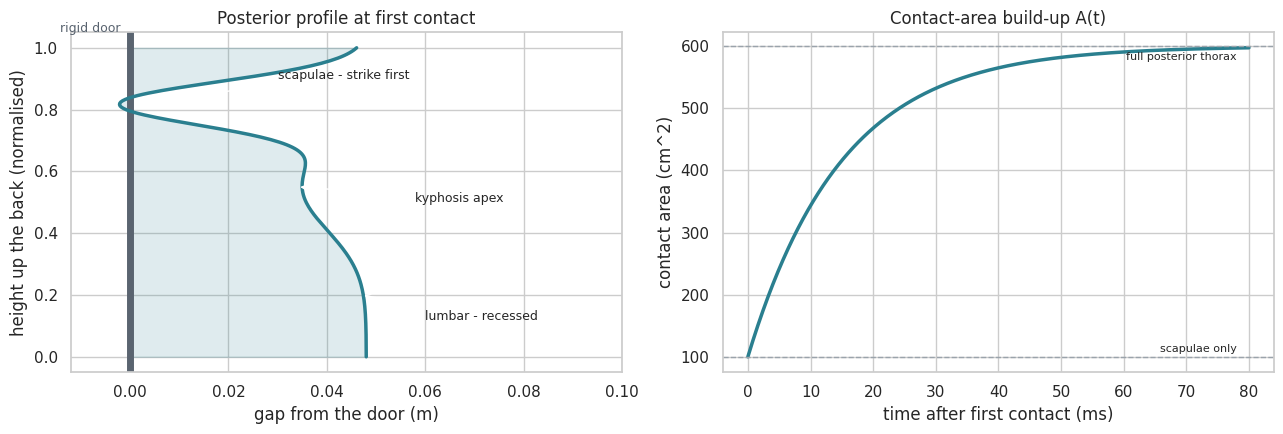

In [7]:
patch_tbl = Table(title="[bold medium_purple]Posterior contact patches - order of contact[/bold medium_purple]",
                  show_header=True, header_style="bold slate_blue1")
patch_tbl.add_column("Order", justify="right")
patch_tbl.add_column("Region")
patch_tbl.add_column("Area (cm^2)", justify="right")
patch_tbl.add_column("Note")
for p in POSTERIOR_PATCHES:
    patch_tbl.add_row(str(p.order), p.name, f"{p.area * 1e4:.0f}", p.note)
console.print(patch_tbl)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
zy = np.linspace(0.0, 1.0, 240)
# gap from the door at first contact - the scapulae touch (gap ~ 0), the
# kyphosis sits back a few cm, the lumbar lordosis is the most recessed
gap = (
    0.048
    - 0.048 * np.exp(-((zy - 0.82) / 0.10) ** 2)
    - 0.013 * np.exp(-((zy - 0.55) / 0.20) ** 2)
)
ax.axvline(0.0, color="#5a6470", lw=5)
ax.plot(gap, zy, color="#2a7f8f", lw=2.5)
ax.fill_betweenx(zy, 0.0, gap, color="#2a7f8f", alpha=0.15)
ax.annotate("scapulae - strike first", xy=(0.002, 0.82), xytext=(0.030, 0.90),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("kyphosis apex", xy=(0.034, 0.55), xytext=(0.058, 0.50),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("lumbar - recessed", xy=(0.047, 0.20), xytext=(0.060, 0.12),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.text(-0.002, 1.05, "rigid door", ha="right", fontsize=9, color="#5a6470")
ax.set_xlabel("gap from the door (m)")
ax.set_ylabel("height up the back (normalised)")
ax.set_title("Posterior profile at first contact")
ax.set_xlim(-0.012, 0.10)

ax = axes[1]
t_area = np.linspace(0.0, 0.08, 400)
a_cm2 = contact_area(t_area, IMPACT) * 1e4
ax.plot(t_area * 1e3, a_cm2, color="#2a7f8f", lw=2.5)
ax.axhline(IMPACT.area_initial * 1e4, color="#9aa3ab", ls="--", lw=1)
ax.axhline(IMPACT.area_final * 1e4, color="#9aa3ab", ls="--", lw=1)
ax.text(78, IMPACT.area_initial * 1e4 + 8, "scapulae only", ha="right", fontsize=8)
ax.text(78, IMPACT.area_final * 1e4 - 22, "full posterior thorax", ha="right", fontsize=8)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("contact area (cm^2)")
ax.set_title("Contact-area build-up A(t)")

fig.tight_layout()
fig.savefig(FIG_DIR / "02-back-contact-patches.png", dpi=140, bbox_inches="tight")
plt.show()


## Posterior-Thorax Chain

The posterior thorax is modelled as a 5-DOF chain of masses and springs - skin, scapula, ribcage, organ, spine - the Lobdell-style anatomical model.  The chain moves at the closing velocity into the rigid door; the skin-to-door contact is Hertzian with Hunt-Crossley damping, capped at an elastic-plastic yield plateau.  The uncapped (elastic) force is the **demand** the impact generates - the quantity the fracture verdict scores; the capped force is what the body could actually transmit before yielding.

The impact is solved at both ends of the kinematics envelope.


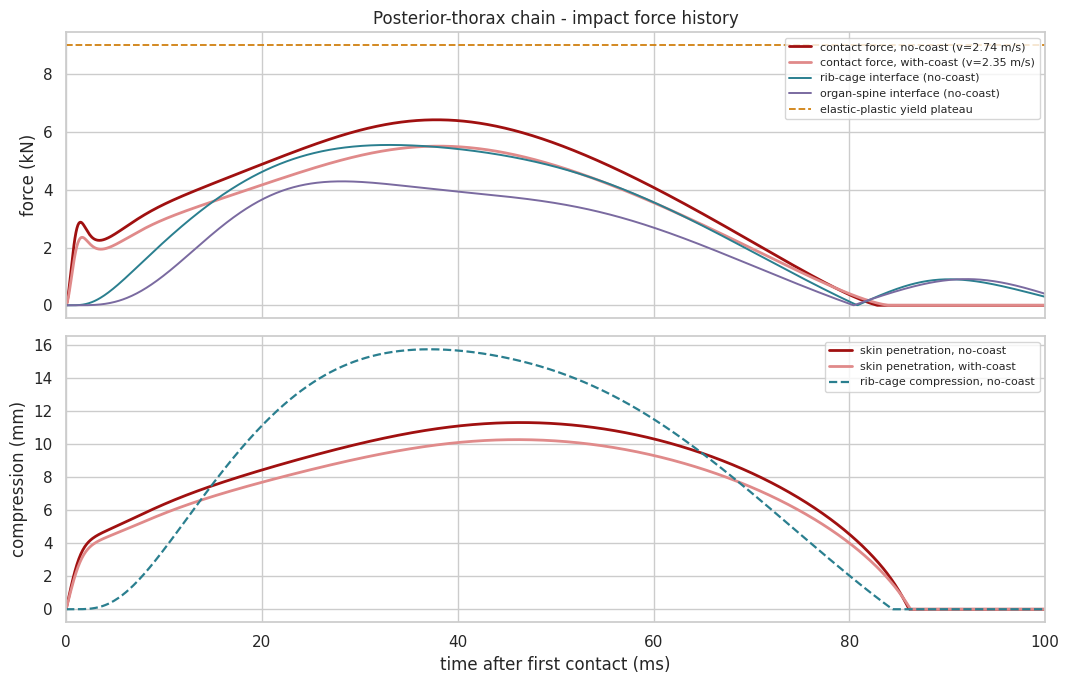

Peak contact force 5.5 - 6.4 kN across the envelope.  Elastic throughout - the 9 kN yield plateau is not reached, 
so there is no plastic body deformation.

In [8]:
fast = solve_impact(IMPACT, V_FAST)
slow = solve_impact(IMPACT, V_SLOW)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
ax.plot(fast.t * 1e3, fast.f_contact / 1e3, color="#a01010", lw=2,
        label=f"contact force, no-coast (v={V_FAST:.2f} m/s)")
ax.plot(slow.t * 1e3, slow.f_contact / 1e3, color="#e08a8a", lw=2,
        label=f"contact force, with-coast (v={V_SLOW:.2f} m/s)")
ax.plot(fast.t * 1e3, fast.f_rib / 1e3, color="#2a7f8f", lw=1.4,
        label="rib-cage interface (no-coast)")
ax.plot(fast.t * 1e3, fast.f_spine / 1e3, color="#7a6aa0", lw=1.4,
        label="organ-spine interface (no-coast)")
ax.axhline(IMPACT.yield_force / 1e3, color="#d08010", ls="--", lw=1.3,
           label="elastic-plastic yield plateau")
ax.set_ylabel("force (kN)")
ax.set_title("Posterior-thorax chain - impact force history")
ax.set_xlim(0, 100)
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(fast.t * 1e3, fast.penetration * 1e3, color="#a01010", lw=2,
        label="skin penetration, no-coast")
ax.plot(slow.t * 1e3, slow.penetration * 1e3, color="#e08a8a", lw=2,
        label="skin penetration, with-coast")
ax.plot(fast.t * 1e3, fast.rib_compression * 1e3, color="#2a7f8f", lw=1.6, ls="--",
        label="rib-cage compression, no-coast")
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("compression (mm)")
ax.set_xlim(0, 100)
ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "02-impact-force-history.png", dpi=140, bbox_inches="tight")
plt.show()

if fast.yields:
    console.print(
        f"Peak contact force {slow.peak_force / 1e3:.1f} - {fast.peak_force / 1e3:.1f} kN; "
        f"the {IMPACT.yield_force / 1e3:.0f} kN yield plateau is crossed - the body "
        f"deforms plastically by {fast.plastic_deformation * 1e3:.1f} mm."
    )
else:
    console.print(
        f"Peak contact force [bold]{slow.peak_force / 1e3:.1f} - "
        f"{fast.peak_force / 1e3:.1f} kN[/bold] across the envelope.  Elastic "
        f"throughout - the {IMPACT.yield_force / 1e3:.0f} kN yield plateau is not "
        f"reached, so there is no plastic body deformation."
    )


## Fracture Thresholds

The computed peaks mean nothing without the corridors to score them against.  These are the published force and deflection thresholds for posterior-thorax blunt impact - rib bending, the rear-torso tolerance, vertebral compression, and the AIS 3+ thoracic deflection.


In [9]:
thr_tbl = Table(title="[bold medium_purple]Fracture and injury thresholds[/bold medium_purple]",
                show_header=True, header_style="bold slate_blue1")
thr_tbl.add_column("Threshold")
thr_tbl.add_column("Value", justify="right")
thr_tbl.add_column("Source")
for thr in fracture_thresholds():
    val = f"{thr.value * 1e3:.0f} mm" if thr.unit == "m" else f"{thr.value / 1e3:.1f} kN"
    thr_tbl.add_row(thr.name, val, thr.source)
console.print(thr_tbl)


                                          Fracture and injury thresholds                                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Threshold                       ┃  Value ┃ Source                                                               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ single rib, three-point bending │ 3.0 kN │ isolated-rib bending tests - fracture 2-5 kN, ~3 kN at 25% risk      │
│ rib fracture per rib (AIS 2+)   │ 1.6 kN │ Viano 1989 - 1.6 kN per loaded rib at AIS 2+                         │
│ posterior thorax tolerance      │ 6.9 kN │ Kemper et al. 2014 - rear-torso impact, 6.9-10.5 kN produces rib and │
│                                 │        │ costo-vertebral injury                                               │
│ vertebral body compression      │ 5.0 kN │ thoracolumbar biomechanics - 4-8 kN healthy vertebral body, 2-3 kN   │
│                                 │        │ osteoporotic; back impact loads the spine in extension, not          │
│                                 │        │ compression                                                          │
│ thoracic deflection (AIS 3+)    │  25 mm │ Cavanaugh 1990 - AIS 3+ thoracic injury at 25 mm deflection          │
└─────────────────────────────────┴────────┴──────────────────────────────────────────────────────────────────────┘

## Predicted Injuries

The fracture corridors above score a handful of structural thresholds. The injury reference table is broader - thirty catalogued injuries of the posterior chest wall, thoracic spine, viscera and shoulder girdle, each carrying an energy, force or pressure onset, an AIS severity and a literature source. `predict_injuries` positions the impact's computed metrics - the no-coast worst case, energy, peak contact force and peak contact pressure - against every row and returns a probability band.

The injury thresholds are differentiated by **sex and age**: `predict_injuries` reads the table for Victoria, a 28-year-old woman, scaling each onset by a tissue-specific tolerance factor. A young adult sits near the bone-strength peak, so the adjustment is small here - it would shift the bone-injury bands markedly for an elderly subject.

Each row's **onset** is that injury's own threshold, so it varies down the table - a bruise, a fractured rib and a burst vertebra each begin at very different severities. **This impact** is the single delivered condition - the same energy, pressure and force on every row; the probability band sets the one against the other.


In [10]:
impact_metrics = {
    "energy": fast.kinetic_energy,
    "force": fast.peak_force,
    "pressure": fast.peak_pressure,
}
band_order = ["certain", "highly probable", "moderately probable",
              "low probability", "impossible"]
predictions = sorted(predict_injuries(impact_metrics, gender=IMPACT.subject_gender,
                                      age=IMPACT.subject_age),
                     key=lambda p: band_order.index(p.probability))


def _metric_lines(energy, pressure, force):
    """Energy, pressure and force stacked in one cell; '--' where absent."""
    return "\n".join([
        f"{energy:.0f} J" if energy is not None else "-- J",
        f"{pressure / 1e3:.0f} kPa" if pressure is not None else "-- kPa",
        f"{force / 1e3:.1f} kN" if force is not None else "-- kN",
    ])


def _onset_cell(metric, onset):
    vals = {"energy": None, "pressure": None, "force": None}
    vals[metric] = onset
    return _metric_lines(vals["energy"], vals["pressure"], vals["force"])


impact_cell = _metric_lines(impact_metrics["energy"], impact_metrics["pressure"],
                            impact_metrics["force"])

band_colour = {
    "certain": "indian_red", "highly probable": "indian_red",
    "moderately probable": "dark_goldenrod", "low probability": "steel_blue",
    "impossible": "dark_sea_green",
}
_subject_age = (f"{IMPACT.subject_age:.0f}" if IMPACT.subject_age is not None
                else "standard")
inj_tbl = Table(title=f"[bold medium_purple]Predicted impact injuries - no-coast "
                f"worst case  (Age: {_subject_age}, Sex: {IMPACT.subject_gender})"
                f"[/bold medium_purple]",
                show_header=True, header_style="bold slate_blue1", show_lines=True)
for col, just in [("Injury", "left"), ("Region", "left"), ("AIS", "center"),
                  ("Injury onset", "right"), ("This impact", "right"),
                  ("Probability", "left"), ("Source", "left")]:
    inj_tbl.add_column(col, justify=just)
for p in predictions:
    inj_tbl.add_row(
        p.injury, p.region, str(p.ais),
        _onset_cell(p.metric, p.onset), impact_cell,
        f"[{band_colour[p.probability]}]{p.probability}[/]", p.source,
    )
console.print(inj_tbl)

counts = {b: sum(p.probability == b for p in predictions) for b in band_order}
console.print(
    f"[bold]Of the 30 catalogued injuries[/bold]: "
    f"[indian_red]{counts['certain']} certain[/indian_red], "
    f"[indian_red]{counts['highly probable']} highly probable[/indian_red], "
    f"[dark_goldenrod]{counts['moderately probable']} moderately probable[/dark_goldenrod], "
    f"[steel_blue]{counts['low probability']} low probability[/steel_blue], "
    f"[dark_sea_green]{counts['impossible']} impossible[/dark_sea_green].  "
    f"Soft-tissue contusion is certain (contact pressure ~4x its onset); a "
    f"posterior rib fracture is highly probable (delivered energy ~4x the "
    f"thoracic rib-fracture onset)."
)


                        Predicted impact injuries - no-coast worst case  (Age: 38, Sex: F)                         
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Injury            ┃ Region            ┃ AIS ┃ Injury onset ┃ This impact ┃ Probability       ┃ Source           ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ skin and          │ posterior chest   │  1  │         -- J │       262 J │ certain           │ StatPearls,      │
│ soft-tissue       │ wall              │     │       50 kPa │     201 kPa │                   │ Blunt Force      │
│ contusion         │                   │     │        -- kN │      6.4 kN │                   │ Trauma           │
│ (bruise)          │                   │     │              │             │                   │ (NBK470338);     │
│                   │                   │     │              │             │                   │ Pathology        │
│                   │                   │     │              │             │                   │ Outlines,        │
│                   │                   │     │              │             │                   │ blunt-force      │
│                   │                   │     │              │             │                   │ injuries         │
├───────────────────┼───────────────────┼─────┼──────────────┼─────────────┼───────────────────┼──────────────────┤
│ deep paraspinal   │ posterior chest   │  1  │         -- J │       262 J │ certain           │ experimental     │
│ muscle contusion  │ wall              │     │       -- kPa │     201 kPa │                   │ human muscle     │
│                   │                   │     │       1.7 kN │      6.4 kN │                   │ contusion        │
│                   │                   │     │              │             │                   │ (PMC9671306)     │
├───────────────────┼───────────────────┼─────┼──────────────┼─────────────┼───────────────────┼──────────────────┤
│ skin abrasion     │ posterior chest   │  1  │         -- J │       262 J │ highly probable   │ StatPearls,      │
│                   │ wall              │     │       60 kPa │     201 kPa │                   │ Blunt Force      │
│                   │                   │     │        -- kN │      6.4 kN │                   │ Trauma           │
│                   │                   │     │              │             │                   │ (NBK470338);     │
│                   │                   │     │              │             │                   │ Trauma Forensics │
│                   │                   │     │              │             │                   │ in Blunt and     │
│                   │                   │     │              │             │                   │ Sharp Force      │
│                   │                   │     │              │             │                   │ Injuries         │
│                   │                   │     │              │             │                   │ (PMC9802595)     │
├───────────────────┼───────────────────┼─────┼──────────────┼─────────────┼───────────────────┼──────────────────┤
│ posterior         │ posterior chest   │  1  │         -- J │       262 J │ highly probable   │ StatPearls,      │
│ soft-tissue       │ wall              │     │       90 kPa │     201 kPa │                   │ haematoma        │
│ haematoma         │                   │     │        -- kN │      6.4 kN │                   │ (NBK519551);     │
│                   │                   │     │              │             │                   │ delayed          │
│                   │                   │     │              │             │                   │ chest-wall       │
│                   │                   │     │              │             │                   │ haematoma        │
│                   │                   │     │         

Of the 30 catalogued injuries: 2 certain, 8 highly probable, 8 moderately probable, 9 low probability, 3 
impossible.  Soft-tissue contusion is certain (contact pressure ~4x its onset); a posterior rib fracture is highly 
probable (delivered energy ~4x the thoracic rib-fracture onset).

## Summary

- The impact modelling lives in `henryk_simulations.corridor.impact` - a library module under the corridor submodule, exercised by 27 test guards.  This notebook is a thin client.
- The body is a **5-DOF Lobdell-style posterior-thorax chain** (skin, scapula, ribcage, organ, spine) struck against the **rigid** elevator door.  The rigid door and the whole-body chain are both worst-case-for-the-accusation assumptions - they maximise the force.
- Across the kinematics envelope (v_close 2.4-2.7 m/s) the **peak contact force is 5.5-6.4 kN** - below the posterior-thorax injury band (Kemper 6.9-10.5 kN), and elastic throughout: the 9 kN plastic-yield plateau is never reached.
- The **force corridors alone are not crossed**: spread over six to seven ribs the per-rib load (~1 kN) stays under the ~3 kN three-point-bending force, and rib compression (~16 mm) is under the 25 mm AIS 3+ deflection.  That is the force-only reading, and it rests on an even load spread.
- **Verdict**: force is not the whole story.  Weighing the delivered **energy** (262 J, over four times the ~60 J thoracic rib-fracture onset) and the **contact pressure** (~200 kPa, four times the contusion onset) as well, the impact predicts **certain soft-tissue trauma and a highly-probable posterior rib fracture** - of the 30 catalogued injuries, 2 are certain and 8 highly probable.  The benign force-corridor reading holds only under the charitable even-load-spread assumption; energy and pressure do not depend on it.
